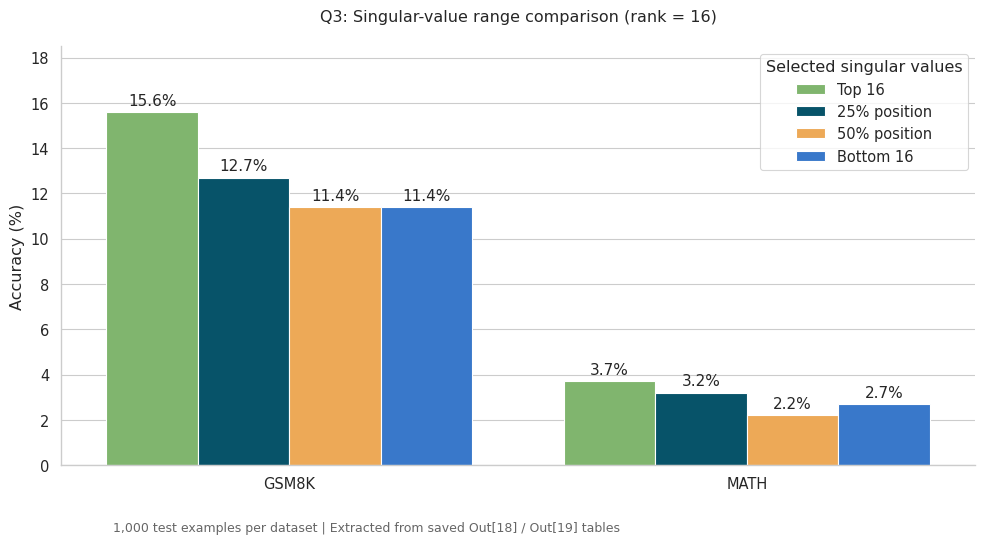

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy values extracted from the saved notebook outputs.
df = pd.DataFrame({
    "Range": [
        "Top 16",
        "25% position",
        "50% position",
        "Bottom 16",
    ],
    "GSM8K": [0.156, 0.127, 0.114, 0.114],
    "MATH": [0.037, 0.032, 0.022, 0.027],
})

plot_df = df.melt(
    id_vars="Range",
    var_name="Dataset",
    value_name="Accuracy",
)
plot_df["Accuracy"] *= 100

sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.2,
)

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.barplot(
    data=plot_df,
    x="Dataset",
    y="Accuracy",
    order=["GSM8K", "MATH"],
    hue="Range",
    hue_order=df["Range"].tolist(),
    palette=["#80B56E", "#075369", "#EDA957", "#3978CA"],
    saturation=1,
    errorbar=None,
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=11,
    )

ax.set_title(
    "Q3: Singular-value range comparison (rank = 16)",
    pad=18,
)
ax.set_xlabel("")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 18.5)
ax.set_yticks(range(0, 19, 2))
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)

ax.legend(
    title="Selected singular values",
    loc="upper right",
    frameon=True,
)

sns.despine(ax=ax)

fig.text(
    0.12, 0.02,
    "1,000 test examples per dataset | "
    "Extracted from saved Out[18] / Out[19] tables",
    fontsize=9,
    color="#666666",
)

fig.tight_layout(rect=[0, 0.06, 1, 1])

fig.savefig("q3_accuracy.png", dpi=300, bbox_inches="tight")
fig.savefig("q3_accuracy.svg", bbox_inches="tight")
plt.show()